## 못씀 성능 개바닥침
### ml_v7 : train, test 데이터셋 분리 방법 변경
* ml_v6 : 무작위 --> ml_v7 : 플랫폼 기준

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings, pickle, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta.csv"
df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)
df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

platform = df_all['store_id'].str.split('_').str[0]
print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{platform.value_counts().to_string()}")
print(f"\nsentiment_score 있음: {df_all['sentiment_score'].notna().sum()}개")
print(f"리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")

c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

sentiment_score 있음: 4411개
리뷰수 있음: 5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413


In [2]:
# ── Y값: 전체 데이터 기준으로 계산 후 플랫폼 분리
df_y = df_all[df_all['sentiment_score'].notna() & df_all['리뷰수'].notna()].copy()

df_y['y1'] = df_y['sentiment_score']
df_y['y2'] = np.log1p(df_y['리뷰수']) / np.log1p(df_y['리뷰수'].max())

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(df_y[['y1', 'y2']])

pca = PCA(n_components=1)
y_pca = pca.fit_transform(y_scaled)
print(f"PCA 분산 설명력: {pca.explained_variance_ratio_[0]:.3f}")

qt = QuantileTransformer(output_distribution='uniform', random_state=42)
df_y['y_pca'] = qt.fit_transform(y_pca)

th_lo = df_y['y_pca'].quantile(0.30)
th_hi = df_y['y_pca'].quantile(0.70)
mask  = (df_y['y_pca'] <= th_lo) | (df_y['y_pca'] >= th_hi)
df_y  = df_y[mask].copy()
df_y['target'] = (df_y['y_pca'] >= th_hi).astype(int)

platform_y = df_y['store_id'].str.split('_').str[0]
print(f"\n전체 학습 가능 데이터: {len(df_y)}개")
print(f"플랫폼별:\n{platform_y.value_counts().to_string()}")
print(f"\n=== 플랫폼 기준 분리 ===")
print(f"Train : Sephora + Amazon")
print(f"Test  : ULTA")

PCA 분산 설명력: 0.512

전체 학습 가능 데이터: 2648개
플랫폼별:
store_id
sephora    1092
amazon      949
ulta        607

=== 플랫폼 기준 분리 ===
Train : Sephora + Amazon
Test  : ULTA


In [3]:
# ── 피처 생성
ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
df_y['ingredient_text'] = df_y[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_y['ingredient_text'].str.lower()

def extract_ml(s):
    if pd.isna(s): return np.nan
    m = re.search(r'([\d.]+)\s*ml', str(s), re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'([\d.]+)\s*oz', str(s), re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    return np.nan
df_y['volume_ml'] = df_y['용량'].apply(extract_ml)

price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)

# 카테고리(중): train 기준으로 valid 범주 결정 (ULTA 제외 후 계산)
train_mask = df_y['store_id'].str.split('_').str[0].isin(['sephora', 'amazon'])
mid_counts = df_y[train_mask]['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)

kbeauty_map = {
    'k_galactomyces': 'galactomyces', 'k_bifida':      'bifida',
    'k_centella':     'centella',     'k_ginseng':     'ginseng',
    'k_snail':        'snail',        'k_beta_glucan': 'beta-glucan',
    'k_bakuchiol':    'bakuchiol',    'k_pdrn':        'polydeoxyribonucleotide|pdrn',
    'k_propolis':     'propolis',
}
for feat, kw in kbeauty_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
k_cols = list(kbeauty_map.keys())
df_y['k_beauty_ratio'] = df_y[k_cols].sum(axis=1) / len(k_cols)

gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_vitamin_c':         'ascorbic',
    'gt_ectoin':            'ectoin',
    'gt_centella_asiatica': 'centella asiatica',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
    'gt_retinol':           'retinol',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_ratio'] = df_y[gt_cols].sum(axis=1) / len(gt_cols)

print("피처 생성 완료")
print(f"카테고리(중) 유효 범주 (train 기준 n≥50): {valid_mid.tolist()}")

피처 생성 완료
카테고리(중) 유효 범주 (train 기준 n≥50): ['cream', 'moisturizers', 'treatments', 'cleansers', 'essence/serum/ampoule', 'eye care', 'masks', 'cleansing foam/gel', 'sunscreen']


In [4]:
# ── 플랫폼 기준 Train/Test 분리
precomp_pos_cols = [
    'niacinamide_position', 'niacinamide_above_1pct',
    'ceramide_position',    'ceramide_above_1pct',
    'hyaluronic_acid_position', 'hyaluronic_acid_above_1pct',
    'zinc_oxide_position',  'zinc_oxide_above_1pct',
    'centella_position',    'centella_above_1pct',
    'pdrn_position',        'pdrn_above_1pct',
    'amino_acid_surfactant_position',
    'top5_active_count',    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]
mid_feat_cols    = [c for c in df_y.columns if c.startswith('mid_')]

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['volume_ml', 'SPF_Index']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + k_cols + ['k_beauty_ratio']
    + gt_cols + ['us_trend_ratio']
    + precomp_pos_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

# 플랫폼 기준 분리
is_train = df_y['store_id'].str.split('_').str[0].isin(['sephora', 'amazon'])
df_train = df_y[is_train]
df_test  = df_y[~is_train]  # ULTA

X_train = df_train[feat_cols].fillna(0).astype(float).values
y_train = df_train['target'].values
X_test  = df_test[feat_cols].fillna(0).astype(float).values
y_test  = df_test['target'].values

print(f"피처 수: {len(feat_cols)}개")
print(f"Train (Sephora+Amazon): {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})")
print(f"Test  (ULTA):           {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

피처 수: 67개
Train (Sephora+Amazon): 2041개  (긍정=972, 부정=1069)
Test  (ULTA):           607개   (긍정=352, 부정=255)

베이스라인 Train CV AUC: 0.7223


In [5]:
# ── Importance Pruning (Train 기준)
low_cov = [c for c in gt_cols if df_train[c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]
print(f"커버리지 5% 미만 제거 ({len(low_cov)}개): {low_cov}")

lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_full.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=feat_cols_pruned)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"Importance=0 제거 ({len(zero_imp)}개): {zero_imp}")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]
feat_cols = feat_cols_pruned

auc_pruned = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                            X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n정제 후 Train CV AUC: {auc_pruned:.4f}")

print("\nTop 20 피처 중요도:")
print(imp[feat_cols_pruned].sort_values(ascending=False).head(20).to_string())

커버리지 5% 미만 제거 (11개): ['gt_tocopherol', 'gt_caprylic', 'gt_pdrn', 'gt_exosome', 'gt_nad', 'gt_bakuchiol', 'gt_azelaic_acid', 'gt_tranexamic_acid', 'gt_ectoin', 'gt_centella_asiatica', 'gt_squalane']
Importance=0 제거 (11개): ['mid_sunscreen', 'k_galactomyces', 'k_bifida', 'k_snail', 'k_beta_glucan', 'k_pdrn', 'k_propolis', 'zinc_oxide_above_1pct', 'centella_above_1pct', 'pdrn_position', 'pdrn_above_1pct']
최종 피처 수: 45개

정제 후 Train CV AUC: 0.7229

Top 20 피처 중요도:
us_trend_ingredient_position      515
hyaluronic_acid_position          354
volume_ml                         328
us_trend_ratio                    222
niacinamide_position              177
price_low                         108
ceramide_position                  88
SPF_Index                          79
top5_active_count                  79
price_mid                          68
amino_acid_surfactant_position     62
price_high                         58
gt_peptide                         52
gt_tocopheryl_acetate              51
gt_sodi

In [6]:
# ── RandomizedSearch + GridSearch (Train만 사용)
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(4, 12),
    'num_leaves':        randint(20, 100),
    'learning_rate':     uniform(0.01, 0.09),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 0.1),
    'reg_lambda':        uniform(0, 0.1),
}
rs = RandomizedSearchCV(LGBMClassifier(random_state=42, verbose=-1),
                        param_distributions=param_dist, n_iter=100,
                        scoring='roc_auc', cv=skf, random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
print(f"RandomizedSearch Train CV AUC: {rs.best_score_:.4f}")

bp = rs.best_params_
param_grid = {
    'n_estimators':      [max(100, bp['n_estimators']-50), bp['n_estimators'], bp['n_estimators']+50],
    'max_depth':         [max(3, bp['max_depth']-1), bp['max_depth'], bp['max_depth']+1],
    'num_leaves':        [max(10, bp['num_leaves']-10), bp['num_leaves'], bp['num_leaves']+10],
    'learning_rate':     [round(bp['learning_rate']*0.8, 4), round(bp['learning_rate'], 4), round(bp['learning_rate']*1.2, 4)],
    'min_child_samples': [max(5, bp['min_child_samples']-5), bp['min_child_samples'], bp['min_child_samples']+5],
}
fixed = dict(colsample_bytree=bp['colsample_bytree'], subsample=bp['subsample'],
             reg_alpha=bp['reg_alpha'], reg_lambda=bp['reg_lambda'],
             random_state=42, verbose=-1)

gs = GridSearchCV(LGBMClassifier(**fixed), param_grid=param_grid,
                  scoring='roc_auc', cv=skf, n_jobs=-1)
gs.fit(X_train, y_train)
print(f"GridSearch Train CV AUC: {gs.best_score_:.4f}")
print(f"최적 파라미터: {gs.best_params_}")

RandomizedSearch Train CV AUC: 0.7431
GridSearch Train CV AUC: 0.7468
최적 파라미터: {'learning_rate': 0.0148, 'max_depth': 8, 'min_child_samples': 23, 'n_estimators': 125, 'num_leaves': 18}


Train CV AUC  : 0.7468
Test AUC (ULTA): 0.5832
과적합 갭      : +0.1636

[Test - ULTA] Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.59      0.54       255
           1       0.65      0.56      0.60       352

    accuracy                           0.57       607
   macro avg       0.57      0.57      0.57       607
weighted avg       0.58      0.57      0.57       607



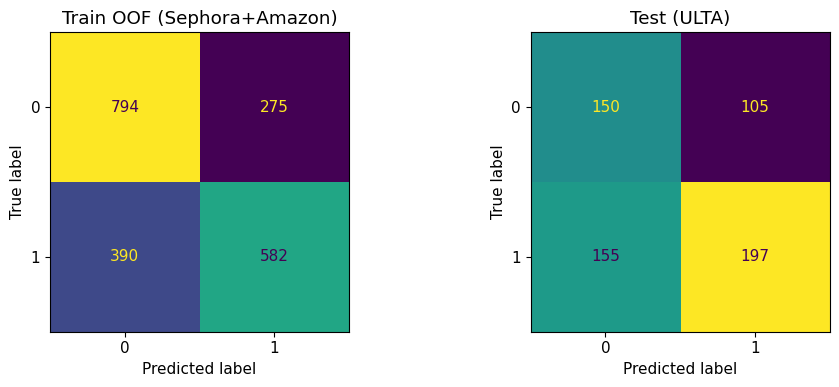


=== 성능 비교 ===
ml_v4 기준                  : 0.7357
ml_v6 무작위 분리 Test AUC  : 0.7673
ml_v7 플랫폼 분리 Test AUC  : 0.5832


In [7]:
# ── 최종 ULTA Test 평가
final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"Train CV AUC  : {gs.best_score_:.4f}")
print(f"Test AUC (ULTA): {test_auc:.4f}")
print(f"과적합 갭      : {gs.best_score_ - test_auc:+.4f}")

print(f"\n[Test - ULTA] Classification Report:")
print(classification_report(y_test, final_model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title("Train OOF (Sephora+Amazon)")
ConfusionMatrixDisplay.from_predictions(y_test, final_model.predict(X_test), ax=axes[1], colorbar=False)
axes[1].set_title("Test (ULTA)")
plt.tight_layout()
plt.show()

print(f"\n=== 성능 비교 ===")
print(f"ml_v4 기준                  : 0.7357")
print(f"ml_v6 무작위 분리 Test AUC  : 0.7673")
print(f"ml_v7 플랫폼 분리 Test AUC  : {test_auc:.4f}")